In [1]:
#the import packages
import requests
import pandas as pd
from pandas import json_normalize
import requests
import os
from pathlib import Path
from datetime import datetime, timezone,timedelta,time
from scipy import stats
import json
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from matplotlib.ticker import MultipleLocator


In [3]:
pd.set_option("display.max_columns", None)

In [8]:
def loadDataFromFile(file_name):
    script_dir = Path().resolve().parent
    print(script_dir)
    data_folder = '..'/script_dir / 'dataAnalysis and machine learning'/'data'
    print(data_folder)
    data_folder.mkdir(exist_ok=True)
    
    file_path = data_folder / (file_name + ".json")
    
    if file_path.exists():
        df = pd.read_json(file_path)
        print(f"Loaded {len(df)} records from {file_path}")
        return df
    else:
        print(f"File {file_path} does not exist.")
        return None    

In [5]:
userInputDataRaw = loadDataFromFile("UserPrevious experiments-preprocessed")
timeSeriesData_BIGraw = loadDataFromFile("Data:Previous experiments-preprocessed")

C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning
C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\dataAnalysis and machine learning\data


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\Andreas\\Documents\\PlatformIO\\Projects\\Diploma Project\\dataAnalysis and machine learning\\dataAnalysis and machine learning\\data'

In [ ]:
timeSeriesData_BIGraw = timeSeriesData_BIGraw.set_index("seconds",drop=False)

In [ ]:
a = userInputDataRaw.index
b = timeSeriesData_BIGraw["keys"].unique()
diff_all = list(set(a).symmetric_difference(set(b)))
print(diff_all)  
userInputDataRaw.index = timeSeriesData_BIGraw["keys"].unique()
print(userInputDataRaw.index)

In [ ]:
# Convert back to timedelta
timeSeriesData_BIGraw['timestamp'] = pd.to_timedelta(timeSeriesData_BIGraw['timestamp'], unit='ms')

# Convert back to datetime

timeSeriesData_BIGraw ["datetime_timestamp"]= timeSeriesData_BIGraw['datetime_timestamp'].transform(
    lambda x: pd.to_datetime(x, unit='ms')
)


columns_datetime= [
       'date of experiment', 'actual timestamp StartingExperiment',
       'actual timestamp EndingExperiment']
columns_timedelta = ['time taken total','time taken before insertion',
       'timestamp InsertingSource timedelta',
       'time taken after insertion']
# Ensure target columns are of object type before assignment
userInputDataRaw[columns_datetime] = userInputDataRaw[columns_datetime].astype('object')
userInputDataRaw[columns_timedelta] = userInputDataRaw[columns_timedelta].astype('object')

userInputDataRaw.loc[:,columns_datetime] = userInputDataRaw.loc[:,columns_datetime].apply(lambda x:pd.to_datetime(x, unit='ms'))
userInputDataRaw.loc[:,columns_timedelta] = userInputDataRaw.loc[:,columns_timedelta].apply(lambda x:pd.to_timedelta(x, unit='ms'))

In [ ]:
timeSeriesData_BIG = timeSeriesData_BIGraw.copy()
userInputData = userInputDataRaw.copy()

In [ ]:
#keep the data from the last set experiments made that have the 3 sensors in a triangle shape,they have 16 particular points in the space and the door is closed
room_mask = userInputData["room"].isin(['Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0.5  ,id:2 Π:0.4 Α:1.0'])

open_door_mask = userInputData["are-doors-opened"] != "on"
mask = room_mask & open_door_mask
userInputData = userInputData.loc[mask]
#grab all the data that are contained in those experiments
timeSeriesData_BIG = timeSeriesData_BIG.loc[timeSeriesData_BIG["keys"].isin(userInputData.index)]

In [ ]:
userInputData

In [ ]:
timeSeriesData_BIG

# Split back into dict
dict_of_timeseries = {k: v.drop(columns="keys").reset_index(drop=True) 
             for k, v in timeSeriesData_BIG.groupby("keys")}
for index,data in dict_of_timeseries.items():
    dict_of_timeseries[index] = dict_of_timeseries[index].set_index("seconds",drop=False)

In [ ]:
def plot_position(userInputData,sample_row_of_the_group):
    plt.figure(figsize=(6, 6))  
    position_of_sensors = userInputData.iloc[-1]
    all_positions = userInputData.loc[:, ["x axis", "y axis"]]
    # Extra points
    extra_positions = np.array([
        [position_of_sensors["position of Id=0:BME680:breathVocEquivalent-x axis"], position_of_sensors["position of Id=0:BME680:breathVocEquivalent-y axis"]],
    
        [position_of_sensors["position of Id=1:BME680:breathVocEquivalent-x axis"], position_of_sensors["position of Id=1:BME680:breathVocEquivalent-y axis"]],
        [position_of_sensors["position of Id=2:BME680:breathVocEquivalent-x axis"], position_of_sensors["position of Id=2:BME680:breathVocEquivalent-y axis"]]
    ])
    extra_ids = ["id0","id1", "id2"]
    
    
    room_length = 4.0
    room_width = 3.25
    
    
    # Create scatterplot of the sources of all the particular setup
    #sns.scatterplot(x=positions[:,0], y=positions[:,1])
    sns.scatterplot(data=all_positions, x="x axis", y="y axis", color='blue', s=100, label='User Input Data')
    
    
    
    # Add the positions of sensors
    sns.scatterplot(x=extra_positions[:,0], y=extra_positions[:,1], color='red', s=100)
    x_sensor_highlight = sample_row_of_the_group["x axis"]
    y_sensor_highlight = sample_row_of_the_group["y axis"]
    # Plot a hollow circle around it
    plt.scatter(x_sensor_highlight, y_sensor_highlight, s=500, facecolors='none', edgecolors='green', linewidths=2, label='Highlighted point')  
    # Draw lines and annotate distances
    distances_from_sensors = (
        sample_row_of_the_group["Euclidian distance to Id=0:BME680:breathVocEquivalent"],
        sample_row_of_the_group["Euclidian distance to Id=1:BME680:breathVocEquivalent"],
        sample_row_of_the_group["Euclidian distance to Id=2:BME680:breathVocEquivalent"]
    )
    
    for i, (x, y) in enumerate(extra_positions):
        plt.plot([x_sensor_highlight, x], [y_sensor_highlight, y], color='red', linewidth=0.7, alpha=0.7)
        
        if distances_from_sensors is not None:
            # Midpoint of the line for annotation
            mid_x = (x_sensor_highlight + x) / 2
            mid_y = (y_sensor_highlight + y) / 2
            plt.text(mid_x, mid_y, f"{distances_from_sensors[i]:.2f}", color='red', fontsize=8, ha='center', va='center',
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=1))
    # Annotate extra points with their IDs
    for i, (x, y) in enumerate(extra_positions):
        plt.text(x, y, extra_ids[i], fontsize=12, ha='right', va='bottom', color='red')
    
    
    # Set axis limits
    plt.xlim(-room_width, 0)
    plt.ylim(0, room_length)
    
    # Add grid
    plt.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.7)
    # Smaller legend
    plt.legend(fontsize=8, markerscale=0.8, labelspacing=0.4)

    plt.show()

In [ ]:
def printDataBasedOnDate(column_to_print,userInputData,timeSeriesData_BIG,room_other_grouping,type_of_other_grouping):
    
    column_names_keys_color_values = {"Id=0:BME680:breathVocEquivalent":"blue","Id=1:BME680:breathVocEquivalent":"green","Id=2:BME680:breathVocEquivalent":"yellow"}
    
    for group_name,indexes_of_the_group in room_other_grouping.items(): 
        timeSeriesData_BIG_copy = timeSeriesData_BIG.copy() 

        if ("position"  in type_of_other_grouping):
            sample_row_of_the_group = userInputData.loc[indexes_of_the_group[0],:]
            
            plot_position(userInputData,sample_row_of_the_group)       
        print(f"group_name {group_name}")
        print(f"indexes_of_the_group {indexes_of_the_group}")
        data = timeSeriesData_BIG_copy.loc[timeSeriesData_BIG_copy["keys"].isin(indexes_of_the_group),:]  
      # Create relplot
        g = sns.relplot(
            data=data,
            x="seconds",
            y=column_to_print,
            hue="sensors",
            col="keys",        # separate subplot per key
            kind="line",
            col_wrap=3, 
                height=7,    # default = 5
            aspect=1, # width = height × aspect (so 6 × 1.5 = 9 inches wide per subplot
            palette=column_names_keys_color_values,  # <<< ensures the same colors across all subplots  
            linewidth=2,
           facet_kws={
            "sharex": False,
            "sharey": False       
    
        })
        

        # >>> ADD THIS PART <<<
        for ax in g.axes.flat:
            ax.xaxis.set_major_locator(MultipleLocator(30))
            ax.xaxis.set_minor_locator(MultipleLocator(10))
            ax.grid(True, which='both', linestyle=':', linewidth=0.5)
            
 
        
    # Get the horizontal and  vertical line position for this experiment
        for key_value, ax in g.axes_dict.items():
           
                #value to show the time that source is inserted
          
            userInputDataRow = userInputData.loc[key_value,:]
        #    x_position = f"side-right-wall {userInputDataRow['side-right-wall']},side-left-wall {userInputDataRow['side-left-wall']} \n"
        #    y_position = f"front-wall {userInputDataRow['front-wall']},back-wall {userInputDataRow['back-wall']} \n"
            
            euclidian_distances = (
                                  f"distance from Id0 sensor {userInputDataRow['Euclidian distance to Id=0:BME680:breathVocEquivalent']}\n",
                                  f"distance from Id1 sensor {userInputDataRow['Euclidian distance to Id=1:BME680:breathVocEquivalent']}\n",
                                  f"distance from Id2 sensor {userInputDataRow['Euclidian distance to Id=2:BME680:breathVocEquivalent']}\n",
            )
            subtitle=  (
                        f"At experiment with key {key_value}\n datetime:{userInputDataRow['actual timestamp StartingExperiment']}\n", 
                        f"experimentState:{userInputDataRow['experimentState']}\n",
                        f"x-axis: {userInputDataRow['x axis']} , y-axis: {userInputDataRow['y axis']}\n"
            )
            if ("distance"  in type_of_other_grouping):
               subtitle = subtitle + euclidian_distances  
            ax.set_title(subtitle, fontsize=9)   
            g.fig.suptitle(f"Group: {group_name}", fontsize=16)
        
            g.fig.subplots_adjust(
                    top=0.75,   # space for overall title
                    wspace=0.2, # horizontal space between subplots
                    hspace=0.3 # vertical space between subplots
                   )

        plt.show()   
             

In [ ]:
def plot_all_positions(userInputData):
    room_other_grouping = userInputData.groupby(["x axis","y axis"]).groups
    
    for group_name,indexes_of_the_group in room_other_grouping.items(): 
        sample_row_of_the_group = userInputData.loc[indexes_of_the_group[0],:]
        plot_position(userInputData,sample_row_of_the_group)      
        
plot_all_positions(userInputData)

sensors = timeSeriesData_BIG["sensors"].unique()
euclidian_distances_columns = [f"Euclidian distance to {sensor}" for sensor in sensors ]
group_by_list = ["room","experimentState",*euclidian_distances_columns]
room_other_grouping = userInputData.groupby(group_by_list).groups
type_of_other_grouping = ["experimentState","position","distance"]

sensors = timeSeriesData_BIG["sensors"].unique()
for sensor in sensors:
    mask = timeSeriesData_BIG["sensors"] == sensor
    timeSeriesData_BIG_subset = timeSeriesData_BIG.loc[mask,:]
    print(sensor)
    printDataBasedOnDate("VOC",userInputData,timeSeriesData_BIG_subset,room_other_grouping,type_of_other_grouping)

sensors = timeSeriesData_BIG["sensors"].unique()
euclidian_distances_columns = [f"Euclidian distance to {sensor}" for sensor in sensors ]
group_by_list = ["room","experimentState",*euclidian_distances_columns]
room_other_grouping = userInputData.groupby(group_by_list).groups
type_of_other_grouping = ["experimentState","position","distance"]

sensors = timeSeriesData_BIG["sensors"].unique()
for sensor in sensors:
    mask = timeSeriesData_BIG["sensors"] == sensor
    timeSeriesData_BIG_subset = timeSeriesData_BIG.loc[mask,:]
    print(sensor)
    printDataBasedOnDate("VOC rolling average",userInputData,timeSeriesData_BIG_subset,room_other_grouping,type_of_other_grouping)

In [ ]:
room_mask = userInputData["room"] == 'Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0.5  ,id:2 Π:0.4 Α:1.0'
experiment_state_mask = userInputData["experimentState"] == "InsertingSourcePollutant"
userInputDataModel = userInputData.loc[room_mask & experiment_state_mask].copy()
df_filtered = timeSeriesData_BIG.loc[timeSeriesData_BIG["keys"].isin(userInputDataModel.index)]
dfs_by_sensor = {
    sensor: g
    for sensor, g in df_filtered.groupby("sensors")
}


In [ ]:
dfs_by_sensor

In [6]:
dfs_by_sensor['Id=0:BME680:breathVocEquivalent'].columns

NameError: name 'dfs_by_sensor' is not defined

In [168]:
userInputDataModel

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,time taken before insertion,time taken before insertion (seconds),time taken after insertion (seconds),time taken total (seconds),time taken total (seconds)-capped,time taken before insertion (seconds)-capped,time taken after insertion (seconds)-capped,Id=1:BME680:breathVocEquivalent MAX value VOC rolling average,Id=1:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent index of MAX value VOC rolling average,sensor with MAX value experiment,sensor with second MAX value experiment,Id=1:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=1:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,whole experiment quantile 90.0% VOC rolling average,whole experiment quantile 99.0% VOC rolling average,Id=1:BME680:breathVocEquivalent VOC mean calm period,Id=1:BME680:breathVocEquivalent VOC gradient mean calm period,Id=2:BME680:breathVocEquivalent VOC mean calm period,Id=2:BME680:breathVocEquivalent VOC gradient mean calm period,Id=0:BME680:breathVocEquivalent VOC mean calm period,Id=0:BME680:breathVocEquivalent VOC gradient mean calm period,x axis,y axis,x-y axises,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis,Euclidian distance to Id=0:BME680:breathVocEquivalent,Euclidian distance to Id=1:BME680:breathVocEquivalent,Euclidian distance to Id=2:BME680:breathVocEquivalent
146,InsertingSourcePollutant,None,None,None,1.5,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,NaN,0.3,None,None,2025-10-13 18:26:12,2025-10-13 18:24:06,2025-10-13 18:57:52,2025-10-13 00:00:00,2025-10-13 18:24:08,2025-10-13 18:57:50,0 days 00:33:42,0 days 00:02:05,125,0 days 00:31:37,0 days 00:02:05,125,1897,2022,270,-30,299,0.3738,251.0,0.3577,294,0.2026,224.0,Id=1:BME680:breathVocEquivalent MAX value VOC ...,Id=2:BME680:breathVocEquivalent MAX value VOC ...,0.34415,0.373413,0.33478,0.357013,0.18951,0.202442,0.32881,0.370132,0.059467,0.001485,0.068867,0.001000,0.087333,0.000453,-2.95,2.5,"[-2.95, 2.5]",-1.85,3.5,-0.5,1.7,-2.25,0.4,1.49,2.58,2.21
147,InsertingSourcePollutant,None,None,None,0.5,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,NaN,0.3,None,None,2025-10-13 19:13:50,2025-10-13 19:11:41,2025-10-13 19:20:00,2025-10-13 00:00:00,2025-10-13 19:11:42,2025-10-13 19:19:59,0 days 00:08:17,0 days 00:02:09,129,0 days 00:06:08,0 days 00:02:09,129,368,497,270,-30,299,0.6778,229.0,0.9853,227,0.6536,299.0,Id=2:BME680:breathVocEquivalent MAX value VOC ...,Id=1:BME680:breathVocEquivalent MAX value VOC ...,0.63975,0.676668,0.95069,0.984642,0.42454,0.643353,0.83994,0.982088,0.170633,0.000088,0.139667,0.001255,0.083233,0.001857,-2.95,3.5,"[-2.95, 3.5]",-1.85,3.5,-0.5,1.7,-2.25,0.4,1.10,3.04,3.18
148,InsertingSourcePollutant,None,None,None,0.5,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0

In [169]:
sensors = timeSeriesData_BIG["sensors"].unique()

euclidian_distances_columns = [f"Euclidian distance to {sensor}" for sensor in sensors ]
userInputDataModel.loc[:,euclidian_distances_columns] = userInputDataModel.loc[:,euclidian_distances_columns].round(2)

In [170]:
userInputDataModel[euclidian_distances_columns].describe().loc[["min","max"]]

,Euclidian distance to Id=0:BME680:breathVocEquivalent,Euclidian distance to Id=1:BME680:breathVocEquivalent,Euclidian distance to Id=2:BME680:breathVocEquivalent
min,0.35,0.20,0.27
max,3.29,3.04,3.56


In [171]:
for column in euclidian_distances_columns:
    print(userInputDataModel[column].unique())

[1.49 1.1  1.35 1.68 2.41 3.29 3.02 2.03 1.06 0.35 0.65 1.19 2.1  3.07
 3.2  2.28]
[2.58 3.04 1.8  0.8  0.2  1.2  1.56 1.02 1.28 2.06 2.69 2.15 2.01 2.33
 2.73 2.46]
[2.21 3.18 3.56 2.73 2.07 1.75 0.76 1.33 2.23 3.19 3.11 2.11 1.13 0.27
 0.71 1.3 ]


In [172]:
columns_to_keep = ["VOC rolling average"]

key_to_grab_size = userInputDataModel.index[0]
mask = dfs_by_sensor['Id=0:BME680:breathVocEquivalent']["keys"] == key_to_grab_size

sample_data = dfs_by_sensor['Id=0:BME680:breathVocEquivalent'].loc[mask,columns_to_keep]
print(sample_data.shape[0])


330


In [173]:


columns_to_keep = ["VOC"]

key_to_grab_size = userInputDataModel.index[0]
mask = dfs_by_sensor['Id=0:BME680:breathVocEquivalent']["keys"] == key_to_grab_size

sample_data = dfs_by_sensor['Id=0:BME680:breathVocEquivalent'].loc[mask,columns_to_keep]

X_subset_columns_size = sample_data.shape[0]


sensors = timeSeriesData_BIG["sensors"].unique()
X ={}
Y ={}


dict_flattened_arrays_per_sensor_per_distance ={}
for sensor in sensors:
    X[sensor] = np.empty((0, X_subset_columns_size))
    Y[sensor] = np.empty((0, 1))
    dict_flattened_arrays_per_sensor_per_distance[sensor] = {}
    euclidian_distance_column = f"Euclidian distance to {sensor}"    
    
    for distance,experiments in userInputDataModel.groupby(euclidian_distance_column):

        rows_size = experiments.shape[0]
        X_distance_subset = np.empty((rows_size,X_subset_columns_size))

        for array_index,experiment_index in enumerate(experiments.index):
          
            mask = dfs_by_sensor[sensor]["keys"]== experiment_index
            flatten_array = dfs_by_sensor[sensor].loc[mask,columns_to_keep].to_numpy().reshape(1, -1)
            
            X_distance_subset[array_index,:] =   flatten_array
        X[sensor] = np.vstack((X[sensor],X_distance_subset))   
            

        Y_distance_subset = np.full((rows_size,1),distance)
        
        Y[sensor] = np.vstack((Y[sensor],Y_distance_subset))   


In [174]:
X

{'Id=0:BME680:breathVocEquivalent': array([[3.11000e-01, 3.19000e-01, 3.26000e-01, ..., 2.37400e+00,
         2.35700e+00, 2.33700e+00],
        [3.64000e-01, 3.64000e-01, 3.61000e-01, ..., 9.98263e+02,
         9.98263e+02, 9.98263e+02],
        [1.38100e+00, 1.37900e+00, 1.38700e+00, ..., 9.97220e+02,
         9.97220e+02, 9.97220e+02],
        ...,
        [4.50000e-02, 4.20000e-02, 3.50000e-02, ..., 4.60000e-02,
         4.30000e-02, 4.00000e-02],
        [2.60000e-01, 2.72000e-01, 2.83000e-01, ..., 7.24000e-01,
         7.25000e-01, 7.18000e-01],
        [4.83000e-01, 4.79000e-01, 4.73000e-01, ..., 2.08600e+00,
         2.08800e+00, 2.10000e+00]]),
 'Id=1:BME680:breathVocEquivalent': array([[5.40000e-02, 4.90000e-02, 4.60000e-02, ..., 2.32910e+01,
         2.31460e+01, 2.30260e+01],
        [2.85500e+00, 2.87700e+00, 2.88100e+00, ..., 3.21510e+01,
         3.11110e+01, 3.00860e+01],
        [2.62000e-01, 2.65000e-01, 2.59000e-01, ..., 9.98626e+02,
         9.98429e+02, 9.94602e+02

In [175]:
Y

{'Id=0:BME680:breathVocEquivalent': array([[0.35],
        [0.35],
        [0.35],
        [0.35],
        [0.35],
        [0.35],
        [0.65],
        [0.65],
        [0.65],
        [0.65],
        [0.65],
        [0.65],
        [1.06],
        [1.06],
        [1.06],
        [1.06],
        [1.06],
        [1.06],
        [1.1 ],
        [1.1 ],
        [1.1 ],
        [1.1 ],
        [1.1 ],
        [1.1 ],
        [1.1 ],
        [1.19],
        [1.19],
        [1.19],
        [1.19],
        [1.19],
        [1.19],
        [1.35],
        [1.35],
        [1.35],
        [1.35],
        [1.35],
        [1.35],
        [1.49],
        [1.49],
        [1.49],
        [1.49],
        [1.49],
        [1.49],
        [1.49],
        [1.68],
        [1.68],
        [1.68],
        [1.68],
        [1.68],
        [1.68],
        [2.03],
        [2.03],
        [2.03],
        [2.03],
        [2.03],
        [2.03],
        [2.1 ],
        [2.1 ],
        [2.1 ],
        [2.1 ],
     

In [176]:
X.keys()

dict_keys(['Id=0:BME680:breathVocEquivalent', 'Id=1:BME680:breathVocEquivalent', 'Id=2:BME680:breathVocEquivalent'])

In [177]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Id=0:BME680:breathVocEquivalent
{'copy': True, 'with_mean': True, 'with_std': True}


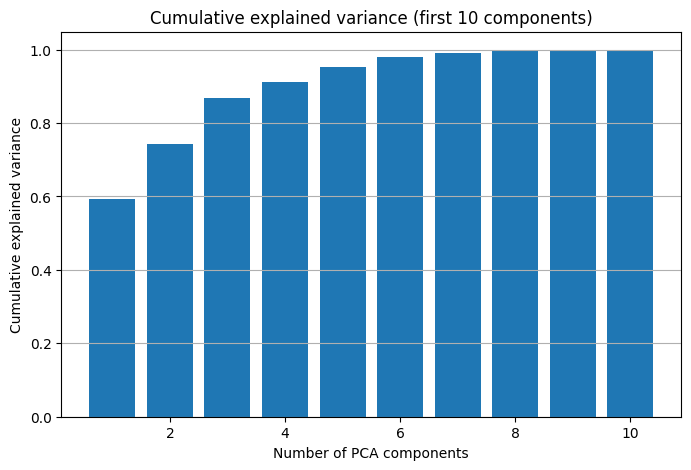

Optimal number of components to explain ~90% variance: 4
Id=1:BME680:breathVocEquivalent
{'copy': True, 'with_mean': True, 'with_std': True}


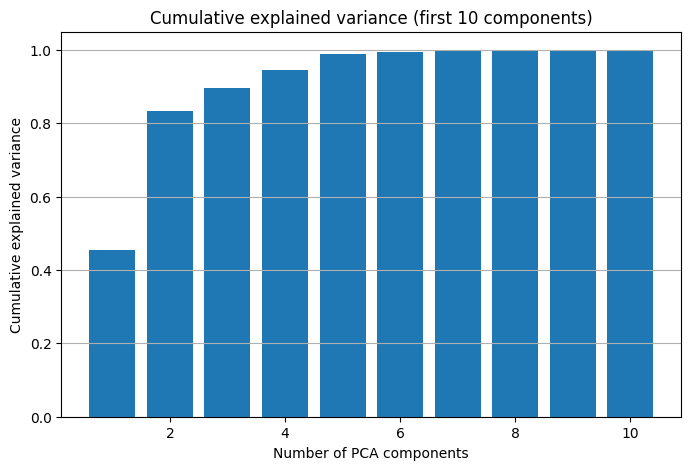

Optimal number of components to explain ~90% variance: 4
Id=2:BME680:breathVocEquivalent
{'copy': True, 'with_mean': True, 'with_std': True}


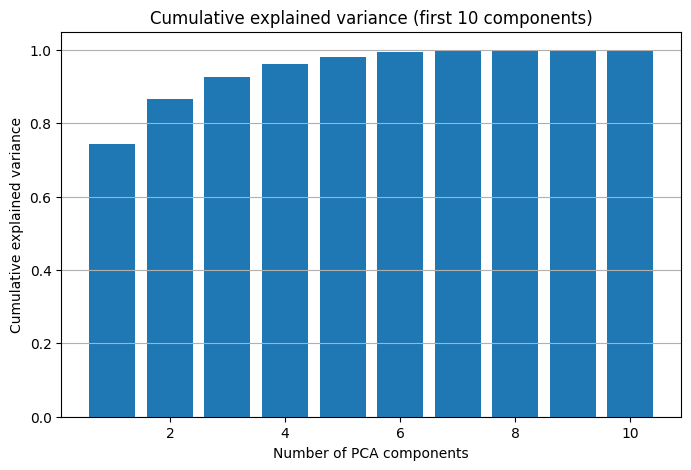

Optimal number of components to explain ~90% variance: 3


In [178]:


sensor_names = ['Id=0:BME680:breathVocEquivalent','Id=1:BME680:breathVocEquivalent','Id=2:BME680:breathVocEquivalent']


for sensor_name in sensor_names:
    print(sensor_name)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X[sensor_name])
    print(scaler.get_params())
    # Step 2: Apply PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    
    # Step 3: Explained variance
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    
    # Only display first 10 components max
    max_components = min(10, len(explained_variance))
    ev_to_plot = explained_variance[:max_components]
    cum_to_plot = cumulative_variance[:max_components]
    
    # Step 4: Bar plot of cumulative explained variance
    plt.figure(figsize=(8,5))
    plt.bar(range(1, max_components + 1), cum_to_plot)
    plt.xlabel('Number of PCA components')
    plt.ylabel('Cumulative explained variance')
    plt.title('Cumulative explained variance (first 10 components)')
    plt.grid(True, axis='y')
    plt.show()
    
    # Step 5: Optimal number of components for ~90% variance
    optimal_components = np.argmax(cumulative_variance >= 0.90) + 1
    print("Optimal number of components to explain ~90% variance:", optimal_components)


In [179]:
# Required imports
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score


In [200]:

# 1. Linear Regression (no hyperparameters to tune, just for completeness)
lr = LinearRegression()
lr_params = {}  # No parameters for simple LinearRegression

# 2. Ridge Regression
ridge = Ridge()
ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr']
}

# 3. Lasso Regression
lasso = Lasso(max_iter=10000)
lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
}

# 4. ElasticNet
elastic = ElasticNet(max_iter=10000)
elastic_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9]
}

# 5. Support Vector Regression
svr = SVR(kernel="rbf")
svr_params = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.001, 0.01, 0.1, 0.2],
    "gamma": ["scale", "auto"]
}


# 7. Random Forest Regression
rf = RandomForestRegressor()
rf_params = {
    'n_estimators': [10, 50, 100,200],
    'max_depth': [ 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 8. Gradient Boosting Regression
gbr = GradientBoostingRegressor()
gbr_params = {
    'n_estimators': [10, 50, 100,200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [ 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

models = {
    'LinearRegression': (lr, lr_params),
    'Ridge': (ridge, ridge_params),
    'Lasso': (lasso, lasso_params),
    'ElasticNet': (elastic, elastic_params),
    'SVR': (svr, svr_params),
    'DecisionTree': (dt, dt_params),
    'RandomForest': (rf, rf_params),
    'GradientBoosting': (gbr, gbr_params)
}




In [203]:
def run_grid_search(X_train, y_train, models):
    results = {}
    
    for name, (model, params) in models.items():
        print(f"Running GridSearchCV for {name}...")

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('PCA', PCA(n_components=n_components, random_state=random_state)),
            ('model', model)
        ])

        # Build a correct param grid:
        param_grid = {
            'PCA__n_components': [3,4,5,6,8,10,15],
            **{'model__' + k: v for k, v in params.items() if not k.startswith("PCA")}
        }
        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            cv=3,
            n_jobs=-1,
            scoring='neg_mean_squared_error',
            verbose=2
        )

        grid.fit(X_train, y_train)

        results[name] = (grid.best_params_, grid.best_score_)

        print(f"{name} best score: {grid.best_score_}")
        print(f"{name} best params: {grid.best_params_}\n")

    return results

In [204]:
#n_components = 5        # number of PCA components you chose
test_size = 0.1         # number of data taken
random_state = 42         # predefined random state for reproducibility

results_of_grid_search={}
for sensor_name in sensor_names:
    X_arr = np.asarray(X[sensor_name])
    Y_arr = np.asarray(Y[sensor_name])
    print(f"running grid search for sensor:{sensor_name}")
    # --- Train/test split ---
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_arr, Y_arr, test_size=test_size, random_state=random_state, shuffle=True
    )
    results_of_grid_search[sensor_name] = run_grid_search(X_train,y_train,models)

running grid search for sensor:Id=0:BME680:breathVocEquivalent
Running GridSearchCV for LinearRegression...
Fitting 3 folds for each of 7 candidates, totalling 21 fits
LinearRegression best score: -21.591088791014702
LinearRegression best params: {'PCA__n_components': 5}

Running GridSearchCV for Ridge...
Fitting 3 folds for each of 140 candidates, totalling 420 fits
Ridge best score: -21.02225670988723
Ridge best params: {'PCA__n_components': 5, 'model__alpha': 100, 'model__solver': 'lsqr'}

Running GridSearchCV for Lasso...
Fitting 3 folds for each of 35 candidates, totalling 105 fits
Lasso best score: -0.8174121802295451
Lasso best params: {'PCA__n_components': 3, 'model__alpha': 10}

Running GridSearchCV for ElasticNet...
Fitting 3 folds for each of 140 candidates, totalling 420 fits
ElasticNet best score: -0.816863266503861
ElasticNet best params: {'PCA__n_components': 3, 'model__alpha': 10, 'model__l1_ratio': 0.5}

Running GridSearchCV for SVR...
Fitting 3 folds for each of 224 c

C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR best score: -0.6681891731661432
SVR best params: {'PCA__n_components': 8, 'model__C': 1, 'model__epsilon': 0.001, 'model__gamma': 'scale'}

Running GridSearchCV for DecisionTree...
Fitting 3 folds for each of 252 candidates, totalling 756 fits
DecisionTree best score: -0.7864318077631941
DecisionTree best params: {'PCA__n_components': 3, 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}

Running GridSearchCV for RandomForest...
Fitting 3 folds for each of 1008 candidates, totalling 3024 fits


C:\Python311\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForest best score: -0.6386922422105671
RandomForest best params: {'PCA__n_components': 15, 'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 10}

Running GridSearchCV for GradientBoosting...
Fitting 3 folds for each of 2268 candidates, totalling 6804 fits


...

C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR best score: -0.8878258877988872
SVR best params: {'PCA__n_components': 8, 'model__C': 1, 'model__epsilon': 0.01, 'model__gamma': 'scale'}

Running GridSearchCV for DecisionTree...
Fitting 3 folds for each of 252 candidates, totalling 756 fits
DecisionTree best score: -1.1791576451478292
DecisionTree best params: {'PCA__n_components': 3, 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}

Running GridSearchCV for RandomForest...
Fitting 3 folds for each of 1008 candidates, totalling 3024 fits


C:\Python311\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForest best score: -0.882759482417499
RandomForest best params: {'PCA__n_components': 6, 'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 10}

Running GridSearchCV for GradientBoosting...
Fitting 3 folds for each of 2268 candidates, totalling 6804 fits
GradientBoosting best score: -0.9062827737707564
GradientBoosting best params: {'PCA__n_components': 6, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 100}



C:\Python311\Lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [204]:
#n_components = 5        # number of PCA components you chose
test_size = 0.1         # number of data taken
random_state = 42         # predefined random state for reproducibility

results_of_grid_search={}
for sensor_name in sensor_names:
    X_arr = np.asarray(X[sensor_name])
    Y_arr = np.asarray(Y[sensor_name])
    print(f"running grid search for sensor:{sensor_name}")
    # --- Train/test split ---
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_arr, Y_arr, test_size=test_size, random_state=random_state, shuffle=True
    )
    results_of_grid_search[sensor_name] = run_grid_search(X_train,y_train,models)

running grid search for sensor:Id=0:BME680:breathVocEquivalent
Running GridSearchCV for LinearRegression...
Fitting 3 folds for each of 7 candidates, totalling 21 fits
LinearRegression best score: -21.591088791014702
LinearRegression best params: {'PCA__n_components': 5}

Running GridSearchCV for Ridge...
Fitting 3 folds for each of 140 candidates, totalling 420 fits
Ridge best score: -21.02225670988723
Ridge best params: {'PCA__n_components': 5, 'model__alpha': 100, 'model__solver': 'lsqr'}

Running GridSearchCV for Lasso...
Fitting 3 folds for each of 35 candidates, totalling 105 fits
Lasso best score: -0.8174121802295451
Lasso best params: {'PCA__n_components': 3, 'model__alpha': 10}

Running GridSearchCV for ElasticNet...
Fitting 3 folds for each of 140 candidates, totalling 420 fits
ElasticNet best score: -0.816863266503861
ElasticNet best params: {'PCA__n_components': 3, 'model__alpha': 10, 'model__l1_ratio': 0.5}

Running GridSearchCV for SVR...
Fitting 3 folds for each of 224 c

C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR best score: -0.6681891731661432
SVR best params: {'PCA__n_components': 8, 'model__C': 1, 'model__epsilon': 0.001, 'model__gamma': 'scale'}

Running GridSearchCV for DecisionTree...
Fitting 3 folds for each of 252 candidates, totalling 756 fits
DecisionTree best score: -0.7864318077631941
DecisionTree best params: {'PCA__n_components': 3, 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}

Running GridSearchCV for RandomForest...
Fitting 3 folds for each of 1008 candidates, totalling 3024 fits


C:\Python311\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForest best score: -0.6386922422105671
RandomForest best params: {'PCA__n_components': 15, 'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 10}

Running GridSearchCV for GradientBoosting...
Fitting 3 folds for each of 2268 candidates, totalling 6804 fits


...

C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR best score: -0.8878258877988872
SVR best params: {'PCA__n_components': 8, 'model__C': 1, 'model__epsilon': 0.01, 'model__gamma': 'scale'}

Running GridSearchCV for DecisionTree...
Fitting 3 folds for each of 252 candidates, totalling 756 fits
DecisionTree best score: -1.1791576451478292
DecisionTree best params: {'PCA__n_components': 3, 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}

Running GridSearchCV for RandomForest...
Fitting 3 folds for each of 1008 candidates, totalling 3024 fits


C:\Python311\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForest best score: -0.882759482417499
RandomForest best params: {'PCA__n_components': 6, 'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 10}

Running GridSearchCV for GradientBoosting...
Fitting 3 folds for each of 2268 candidates, totalling 6804 fits
GradientBoosting best score: -0.9062827737707564
GradientBoosting best params: {'PCA__n_components': 6, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 100}



C:\Python311\Lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [205]:
results_of_grid_search

{'Id=0:BME680:breathVocEquivalent': {'LinearRegression': ({'PCA__n_components': 5},
   -21.591088791014702),
  'Ridge': ({'PCA__n_components': 5,
    'model__alpha': 100,
    'model__solver': 'lsqr'},
   -21.02225670988723),
  'Lasso': ({'PCA__n_components': 3, 'model__alpha': 10}, -0.8174121802295451),
  'ElasticNet': ({'PCA__n_components': 3,
    'model__alpha': 10,
    'model__l1_ratio': 0.5},
   -0.816863266503861),
  'SVR': ({'PCA__n_components': 8,
    'model__C': 1,
    'model__epsilon': 0.001,
    'model__gamma': 'scale'},
   -0.6681891731661432),
  'DecisionTree': ({'PCA__n_components': 3,
    'model__max_depth': 5,
    'model__min_samples_leaf': 4,
    'model__min_samples_split': 10},
   -0.7864318077631941),
  'RandomForest': ({'PCA__n_components': 15,
    'model__max_depth': 20,
    'model__min_samples_leaf': 2,
    'model__min_samples_split': 10,
    'model__n_estimators': 10},
   -0.6386922422105671),
  'GradientBoosting': ({'PCA__n_components': 15,
    'model__learning_r

In [206]:
def run_grid_search(X_train, y_train, models):
    results = {}
    
    for name, (model, params) in models.items():
        print(f"Running GridSearchCV for {name}...")

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('PCA', PCA(n_components=n_components, random_state=random_state)),
            ('model', model)
        ])

        # Build a correct param grid:
        param_grid = {
            'PCA__n_components': [3,4,5,6,8,10,15],
            **{'model__' + k: v for k, v in params.items() if not k.startswith("PCA")}
        }
        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            cv=5,
            n_jobs=-1,
            scoring='neg_mean_squared_error',
            verbose=2
        )

        grid.fit(X_train, y_train)

        results[name] = (grid.best_params_, grid.best_score_)

        print(f"{name} best score: {grid.best_score_}")
        print(f"{name} best params: {grid.best_params_}\n")

    return results

In [ ]:
#n_components = 5        # number of PCA components you chose
test_size = 0.2         # number of data taken
random_state = 42         # predefined random state for reproducibility

results_of_grid_search={}
for sensor_name in sensor_names:
    X_arr = np.asarray(X[sensor_name])
    Y_arr = np.asarray(Y[sensor_name])
    print(f"running grid search for sensor:{sensor_name}")
    # --- Train/test split ---
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_arr, Y_arr, test_size=test_size, random_state=random_state, shuffle=True
    )
    results_of_grid_search[sensor_name] = run_grid_search(X_train,y_train,models)

running grid search for sensor:Id=0:BME680:breathVocEquivalent
Running GridSearchCV for LinearRegression...
Fitting 5 folds for each of 7 candidates, totalling 35 fits
LinearRegression best score: -1.1774926354136368
LinearRegression best params: {'PCA__n_components': 3}

Running GridSearchCV for Ridge...
Fitting 5 folds for each of 140 candidates, totalling 700 fits
Ridge best score: -1.1571388933234423
Ridge best params: {'PCA__n_components': 3, 'model__alpha': 100, 'model__solver': 'auto'}

Running GridSearchCV for Lasso...
Fitting 5 folds for each of 35 candidates, totalling 175 fits
Lasso best score: -0.8285791597728391
Lasso best params: {'PCA__n_components': 3, 'model__alpha': 10}

Running GridSearchCV for ElasticNet...
Fitting 5 folds for each of 140 candidates, totalling 700 fits
ElasticNet best score: -0.8285791597728391
ElasticNet best params: {'PCA__n_components': 3, 'model__alpha': 10, 'model__l1_ratio': 0.5}

Running GridSearchCV for SVR...
Fitting 5 folds for each of 224

C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR best score: -0.7105303879500956
SVR best params: {'PCA__n_components': 15, 'model__C': 10, 'model__epsilon': 0.01, 'model__gamma': 'scale'}

Running GridSearchCV for DecisionTree...
Fitting 5 folds for each of 252 candidates, totalling 1260 fits
DecisionTree best score: -0.7219902743492116
DecisionTree best params: {'PCA__n_components': 5, 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}

Running GridSearchCV for RandomForest...
Fitting 5 folds for each of 1008 candidates, totalling 5040 fits


In [ ]:
results_of_grid_search

'Id=0:BME680:breathVocEquivalent'

In [71]:
from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVR
svr_params = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.001, 0.01, 0.1, 0.2],
    "gamma": ["scale", "auto"]
}

svr = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=svr_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

svr.fit(X_train_pca, y_train)
print("SVR best params:", svr.best_params_)

from sklearn.metrics import mean_absolute_error, r2_score

best_model = svr.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________



from sklearn.ensemble import RandomForestRegressor

rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

rf.fit(X_train_pca, y_train)
print("Random Forest best params:", rf.best_params_)


best_model = rf.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.ensemble import GradientBoostingRegressor

gbr_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gbr = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gbr_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

gbr.fit(X_train_pca, y_train)
print("GradientBoosting best params:", gbr.best_params_)

best_model = gbr.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.neighbors import KNeighborsRegressor

knn_params = {
    "n_neighbors": [2, 3, 4, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "p": [1, 2]   # Manhattan / Euclidean
}

knn = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=knn_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

knn.fit(X_train_pca, y_train)
print("KNN best params:", knn.best_params_)


best_model = knn.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.linear_model import Ridge

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

ridge.fit(X_train_pca, y_train)
print("Ridge best params:", ridge.best_params_)

best_model = ridge.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.linear_model import Lasso

lasso_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1]
}

lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=lasso_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

lasso.fit(X_train_pca, y_train)
print("Lasso best params:", lasso.best_params_)


best_model = lasso.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


Fitting 5 folds for each of 32 candidates, totalling 160 fits


C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR best params: {'C': 1, 'epsilon': 0.001, 'gamma': 'scale'}
Test MSE: 0.7319935360761438
Test R² : 0.1674267086443284
Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Python311\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest best params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 50}
Test MSE: 0.8030247839920293
Test R² : 0.08716953792318116
Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Python311\Lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoosting best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}
Test MSE: 0.6857502762934823
Test R² : 0.28716851668291166
Fitting 5 folds for each of 24 candidates, totalling 120 fits
KNN best params: {'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}
Test MSE: 0.7752142857142856
Test R² : 0.11288630112463427
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Ridge best params: {'alpha': 100}
Test MSE: 0.8816042534213713
Test R² : -0.17122600793487597
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Lasso best params: {'alpha': 1}
Test MSE: 0.788868442428885
Test R² : 0.14506961647710226


'Id=1:BME680:breathVocEquivalent'

MSE on test set: 0.5281
R^2 on test set: 0.4178


C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


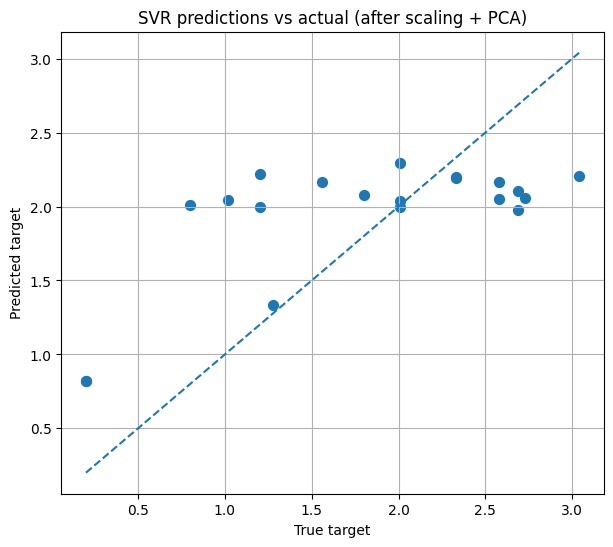

In [72]:
# --- Config ---
n_components = 5       # number of PCA components you chose
test_size = 0.2           # fraction for test set
random_state = 42         # predefined random state for reproducibility

# --- Get arrays (ensure they're numpy arrays) ---
X_arr = np.asarray(X['Id=1:BME680:breathVocEquivalent'])
y_arr = np.asarray(Y['Id=1:BME680:breathVocEquivalent'])


# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y_arr, test_size=test_size, random_state=random_state, shuffle=True
)

# --- Scale: fit on train, transform train & test ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train
X_test_scaled  = scaler.transform(X_test)        # transform only

# --- PCA: fit on scaled train, transform both ---
pca = PCA(n_components=n_components, random_state=random_state)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# --- SVR: train on PCA data ---
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)  # tune C, epsilon, kernel as needed
svr.fit(X_train_pca, y_train)

# --- Predict & evaluate ---
y_pred = svr.predict(X_test_pca)
mse = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MSE on test set: {mse:.4f}")
print(f"R^2 on test set: {r2:.4f}")

# --- Plot: predicted vs actual ---
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("True target")
plt.ylabel("Predicted target")
plt.title("SVR predictions vs actual (after scaling + PCA)")
plt.grid(True)
plt.show()


In [73]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

svr_params = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.001, 0.01, 0.1, 0.2],
    "gamma": ["scale", "auto"]
}

svr = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=svr_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

svr.fit(X_train_pca, y_train)
print("SVR best params:", svr.best_params_)

from sklearn.metrics import mean_absolute_error, r2_score

best_model = svr.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________



from sklearn.ensemble import RandomForestRegressor

rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

rf.fit(X_train_pca, y_train)
print("Random Forest best params:", rf.best_params_)


best_model = rf.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.ensemble import GradientBoostingRegressor

gbr_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gbr = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gbr_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

gbr.fit(X_train_pca, y_train)
print("GradientBoosting best params:", gbr.best_params_)

best_model = gbr.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.neighbors import KNeighborsRegressor

knn_params = {
    "n_neighbors": [2, 3, 4, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "p": [1, 2]   # Manhattan / Euclidean
}

knn = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=knn_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

knn.fit(X_train_pca, y_train)
print("KNN best params:", knn.best_params_)


best_model = knn.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.linear_model import Ridge

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

ridge.fit(X_train_pca, y_train)
print("Ridge best params:", ridge.best_params_)

best_model = ridge.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.linear_model import Lasso

lasso_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1]
}

lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=lasso_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

lasso.fit(X_train_pca, y_train)
print("Lasso best params:", lasso.best_params_)


best_model = lasso.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


Fitting 5 folds for each of 32 candidates, totalling 160 fits


C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR best params: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}
Test MSE: 0.5219516095540987
Test R² : 0.4390375984249042
Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Python311\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Test MSE: 0.5842273699906789
Test R² : 0.35478774338322994
Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Python311\Lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoosting best params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50}
Test MSE: 0.6254451446710527
Test R² : 0.23940241249601035
Fitting 5 folds for each of 24 candidates, totalling 120 fits
KNN best params: {'n_neighbors': 9, 'p': 2, 'weights': 'uniform'}
Test MSE: 0.6498888888888888
Test R² : 0.037566567690780706
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Ridge best params: {'alpha': 100}
Test MSE: 0.764165738862516
Test R² : -1.168133669983523
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Lasso best params: {'alpha': 0.1}
Test MSE: 0.7512194935980461
Test R² : -1.0432396593103412


'Id=2:BME680:breathVocEquivalent'

MSE on test set: 0.7112
R^2 on test set: 0.3593


C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


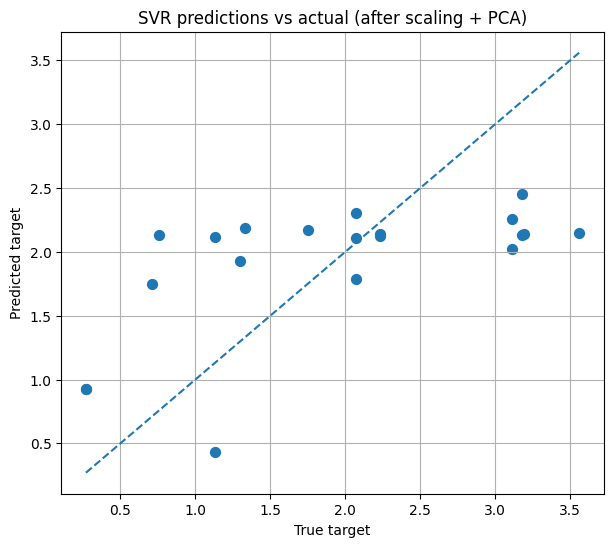

In [74]:
# --- Config ---
n_components = 5        # number of PCA components you chose
test_size = 0.2           # fraction for test set
random_state = 42         # predefined random state for reproducibility

# --- Get arrays (ensure they're numpy arrays) ---
X_arr = np.asarray(X['Id=2:BME680:breathVocEquivalent'])
y_arr = np.asarray(Y['Id=2:BME680:breathVocEquivalent'])


# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y_arr, test_size=test_size, random_state=random_state, shuffle=True
)

# --- Scale: fit on train, transform train & test ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train
X_test_scaled  = scaler.transform(X_test)        # transform only

# --- PCA: fit on scaled train, transform both ---
pca = PCA(n_components=n_components, random_state=random_state)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# --- SVR: train on PCA data ---
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)  # tune C, epsilon, kernel as needed
svr.fit(X_train_pca, y_train)

# --- Predict & evaluate ---
y_pred = svr.predict(X_test_pca)
mse = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MSE on test set: {mse:.4f}")
print(f"R^2 on test set: {r2:.4f}")

# --- Plot: predicted vs actual ---
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("True target")
plt.ylabel("Predicted target")
plt.title("SVR predictions vs actual (after scaling + PCA)")
plt.grid(True)
plt.show()


In [75]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

svr_params = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.001, 0.01, 0.1, 0.2],
    "gamma": ["scale", "auto"]
}

svr = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=svr_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

svr.fit(X_train_pca, y_train)
print("SVR best params:", svr.best_params_)

from sklearn.metrics import mean_absolute_error, r2_score

best_model = svr.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________



from sklearn.ensemble import RandomForestRegressor

rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

rf.fit(X_train_pca, y_train)
print("Random Forest best params:", rf.best_params_)


best_model = rf.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.ensemble import GradientBoostingRegressor

gbr_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gbr = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gbr_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

gbr.fit(X_train_pca, y_train)
print("GradientBoosting best params:", gbr.best_params_)

best_model = gbr.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.neighbors import KNeighborsRegressor

knn_params = {
    "n_neighbors": [2, 3, 4, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "p": [1, 2]   # Manhattan / Euclidean
}

knn = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=knn_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

knn.fit(X_train_pca, y_train)
print("KNN best params:", knn.best_params_)


best_model = knn.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.linear_model import Ridge

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

ridge.fit(X_train_pca, y_train)
print("Ridge best params:", ridge.best_params_)

best_model = ridge.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.linear_model import Lasso

lasso_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1]
}

lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=lasso_params,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

lasso.fit(X_train_pca, y_train)
print("Lasso best params:", lasso.best_params_)


best_model = lasso.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_absolute_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


Fitting 5 folds for each of 32 candidates, totalling 160 fits
SVR best params: {'C': 1, 'epsilon': 0.01, 'gamma': 'scale'}
Test MSE: 0.7056551205032425
Test R² : 0.36505066420885035
Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Python311\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Test MSE: 0.6524099999999998
Test R² : 0.38351877354539154
Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Python311\Lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoosting best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Test MSE: 0.7056221548011035
Test R² : 0.2688813282871959
Fitting 5 folds for each of 24 candidates, totalling 120 fits
KNN best params: {'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
Test MSE: 0.7307585067584526
Test R² : 0.26870738661347027
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Ridge best params: {'alpha': 100}
Test MSE: 0.738154530797442
Test R² : 0.29174731021099565
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Lasso best params: {'alpha': 1}
Test MSE: 0.7218807415755408
Test R² : 0.3007180771326333


In [78]:

# --- Config ---
n_components = 8      # number of PCA components you chose
test_size = 0.2           # fraction for test set
random_state = 42         # predefined random state for reproducibility


sensor_names = ['Id=0:BME680:breathVocEquivalent','Id=1:BME680:breathVocEquivalent','Id=2:BME680:breathVocEquivalent']
# --- Get arrays (ensure they're numpy arrays) ---
for sensor_name in sensor_names

    X_arr = np.asarray(X[sensor_name])
    y_arr = np.asarray(Y[sensor_name])

    # --- Train/test split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_arr, y_arr, test_size=test_size, random_state=random_state, shuffle=True
    )
    mean_squared_error
    # --- Scale: fit on train, transform train & test ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)   # fit on train
    X_test_scaled  = scaler.transform(X_test)        # transform only
    
    # --- PCA: fit on scaled train, transform both ---
    pca = PCA(n_components=n_components, random_state=random_state)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca  = pca.transform(X_test_scaled)
    
    # --- SVR: train on PCA data ---
    svr = SVR(kernel='rbf', C=1, epsilon=0.1)  # tune C, epsilon, kernel as needed
    svr.fit(X_train_pca, y_train)
    
    # --- Predict & evaluate ---
    y_pred = svr.predict(X_test_pca)
    mse = mean_squared_error(y_test, y_pred)
    
    r2  = r2_score(y_test, y_pred)
    
    print(f"MSE on test set: {mse:.4f}")
    
    print(f"R^2 on test set: {r2:.4f}")
    
    # --- Plot: predicted vs actual ---
    plt.figure(figsize=(7,6))
    plt.scatter(y_test, y_pred, s=50)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
    plt.xlabel("True target")
    plt.ylabel("Predicted target")
    plt.title("SVR predictions vs actual (after scaling + PCA)")
    plt.grid(True)
    plt.show()

SyntaxError: expected ':' (3838476992.py, line 9)

In [82]:


# Example: X_train, y_train are your training data

# 1. Linear Regression (no hyperparameters to tune, just for completeness)
lr = LinearRegression()
lr_params = {}  # No parameters for simple LinearRegression

# 2. Ridge Regression
ridge = Ridge()
ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr']
}

# 3. Lasso Regression
lasso = Lasso(max_iter=10000)
lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
}

# 4. ElasticNet
elastic = ElasticNet(max_iter=10000)
elastic_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9]
}

# 5. Support Vector Regression
svr = SVR()
svr_params = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2, 0.5],
    'degree': [2, 3, 4]  # Only relevant for poly kernel
}

# 6. Decision Tree Regression
dt = DecisionTreeRegressor()
dt_params = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 7. Random Forest Regression
rf = RandomForestRegressor()
rf_params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 8. Gradient Boosting Regression
gbr = GradientBoostingRegressor()
gbr_params = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Combine models and parameters in a dictionary
models = {
    'LinearRegression': (lr, lr_params),
    'Ridge': (ridge, ridge_params),
    'Lasso': (lasso, lasso_params),
    'ElasticNet': (elastic, elastic_params),
    'SVR': (svr, svr_params),
    'DecisionTree': (dt, dt_params),
    'RandomForest': (rf, rf_params),
    'GradientBoosting': (gbr, gbr_params)
}


# Usage example
# results = run_grid_search(X_train, y_train, models)

In [85]:

# --- Config ---
n_components = 8      # number of PCA components you chose
test_size = 0.2           # fraction for test set
random_state = 42         # predefined random state for reproducibility


sensor_names = ['Id=0:BME680:breathVocEquivalent','Id=1:BME680:breathVocEquivalent','Id=2:BME680:breathVocEquivalent']
# --- Get arrays (ensure they're numpy arrays) ---
for sensor_name in sensor_names:
    print(f"for the sensor {sensor_name}")
    X_arr = np.asarray(X[sensor_name])
    y_arr = np.asarray(Y[sensor_name])
    
       # Example: X, y are your full dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X_arr, y_arr, test_size=0.2, random_state=42
    )

    mean_squared_error
    # --- Scale: fit on train, transform train & test ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)   # fit on train
    X_test_scaled  = scaler.transform(X_test)        # transform only
    
    # --- PCA: fit on scaled train, transform both ---
    pca = PCA(n_components=n_components, random_state=random_state)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca  = pca.transform(X_test_scaled)
    
       
    run_grid_search(X_train, y_train, models)


for the sensor Id=0:BME680:breathVocEquivalent
Running GridSearchCV for LinearRegression...
LinearRegression best score: -190008.53343395615
LinearRegression best params: {}

Running GridSearchCV for Ridge...
Ridge best score: -54.59399177483859
Ridge best params: {'regressor__alpha': 100, 'regressor__solver': 'lsqr'}

Running GridSearchCV for Lasso...
Lasso best score: -0.1884958124385998
Lasso best params: {'regressor__alpha': 1}

Running GridSearchCV for ElasticNet...
ElasticNet best score: -0.1884958124385998
ElasticNet best params: {'regressor__alpha': 1, 'regressor__l1_ratio': 0.5}

Running GridSearchCV for SVR...


C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR best score: 0.007508878023755661
SVR best params: {'regressor__C': 10, 'regressor__degree': 2, 'regressor__epsilon': 0.01, 'regressor__kernel': 'rbf'}

Running GridSearchCV for DecisionTree...
DecisionTree best score: -0.12490353260519056
DecisionTree best params: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}

Running GridSearchCV for RandomForest...


C:\Python311\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForest best score: 0.011021522356492142
RandomForest best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Running GridSearchCV for GradientBoosting...


...

C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR best score: -0.0024080694843872986
SVR best params: {'regressor__C': 1, 'regressor__degree': 2, 'regressor__epsilon': 0.1, 'regressor__kernel': 'rbf'}

Running GridSearchCV for DecisionTree...
DecisionTree best score: -0.44891269117440513
DecisionTree best params: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}

Running GridSearchCV for RandomForest...


C:\Python311\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForest best score: -0.01650702960701784
RandomForest best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Running GridSearchCV for GradientBoosting...


KeyboardInterrupt: 